#**Problem**
This project utilizes a Kaggle dataset of the most trending YouTube videos from 2017 in India. After preprocessing the data and removing entries with missing values, the top 5,000 videos were selected. The YouTube Data API v3 was then used to collect comments associated with each video through their unique video IDs. Because each video is assigned a predefined category, the comments serve as textual data for training a machine learning model using natural language processing (NLP) techniques. The objective is to predict a video's category based on the content of its comments.

In [14]:
import pandas as pd
df=pd.read_csv('/content/INvideos.csv')
df.head()

,video_id,trending_date,title,channel_title,category_id,publish_time,tags,views,likes,dislikes,comment_count,thumbnail_link,comments_disabled,ratings_disabled,video_error_or_removed,description
0,kzwfHumJyYc,17.14.11,Sharry Mann: Cute Munda ( Song Teaser) | Parmi...,Lokdhun Punjabi,1,2017-11-12T12:20:39.000Z,"sharry mann|""sharry mann new song""|""sharry man...",1096327,33966,798,882,https://i.ytimg.com/vi/kzwfHumJyYc/default.jpg,False,False,False,Presenting Sharry Mann latest Punjabi Song Cu...
1,zUZ1z7FwLc8,17.14.11,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...",HJ NEWS,25,2017-11-13T05:43:56.000Z,"पीरियड्स के समय|""पेट पर पति करता ऐसा""|""देखकर द...",590101,735,904,0,https://i.ytimg.com/vi/zUZ1z7FwLc8/default.jpg,True,False,False,"पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं..."
2,10L1hZ9qa58,17.14.11,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,TFPC,24,2017-11-12T15:48:08.000Z,Stylish Star Allu Arjun @ ChaySam Wedding Rece...,473988,2011,243,149,https://i.ytimg.com/vi/10L1hZ9qa58/default.jpg,False,False,False,Watch Stylish Star Allu Arjun @ ChaySam Weddin...
3,N1vE8iiEg64,17.14.11,Eruma Saani | Tamil vs English,Eruma Saani,23,2017-11-12T07:08:48.000Z,"Eruma Saani|""Tamil Comedy Videos""|""Films""|""Mov...",1242680,70353,1624,2684,https://i.ytimg.com/vi/N1vE8iiEg64/default.jpg,False,False,False,This video showcases the difference between pe...
4,kJzGH0PVQHQ,17.14.11,why Samantha became EMOTIONAL @ Samantha naga ...,Filmylooks,24,2017-11-13T01:14:16.000Z,"Filmylooks|""latest news""|""telugu movies""|""telu...",464015,492,293,66,https://i.ytimg.com/vi/kJzGH0PVQHQ/default.jpg,False,False,False,why Samantha became EMOTIONAL @ Samantha naga ...


In [15]:
cols=['comments_disabled','ratings_disabled','video_error_or_removed']
df=df[~df[cols].any(axis=1)]

In [16]:
df=df[['video_id','category_id']]
df.head()

,video_id,category_id
0,kzwfHumJyYc,1
2,10L1hZ9qa58,24
3,N1vE8iiEg64,23
4,kJzGH0PVQHQ,24
5,il_pSa5l98w,24


In [17]:
df=df.dropna()

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35716 entries, 0 to 37351
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   video_id     35716 non-null  object
 1   category_id  35716 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 837.1+ KB


In [19]:
'''from googleapiclient.discovery import build

API_KEY = "Deleted :)"

youtube = build(
    "youtube",
    "v3",
    developerKey=API_KEY
)
from googleapiclient.errors import HttpError
import pandas as pd

def get_comments(video_id, max_comments=20):
    comments = []

    try:
        request = youtube.commentThreads().list(
            part="snippet",
            videoId=video_id,
            maxResults=min(max_comments, 100),
            textFormat="plainText"
        )

        response = request.execute()

        for item in response["items"]:
            comments.append(
                item["snippet"]["topLevelComment"]["snippet"]["textDisplay"]
            )

        return comments

    except HttpError:
        return []

    except Exception:
        return []


target_videos = 5000
videos_with_comments = []

for _, row in df.iterrows():

    comments = get_comments(
        row["video_id"],
        max_comments=20
    )

    # Keep only videos that actually returned comments
    if len(comments) > 0:

        row_dict = row.to_dict()
        row_dict["comments"] = comments

        videos_with_comments.append(row_dict)

        print(
            f"Collected {len(videos_with_comments)}/{target_videos}",
            end="\r"
        )

    # Stop once we have 1000 successful videos
    if len(videos_with_comments) >= target_videos:
        break


comments_df = pd.DataFrame(videos_with_comments)

print(f"\nFinal videos collected: {len(comments_df)}")
comments_df.to_csv(
    "5000_youtube_videos_with_comments.csv",
    index=False
)'''

Collected 5000/5000
Final videos collected: 5000


In [70]:
dfc=pd.read_csv('/content/5000_youtube_videos_with_comments.csv')
dfc.head()

,video_id,category_id,comments
0,kzwfHumJyYc,1,"['Teaser', 'Supr', 'Vgoofsong', 'Nice song', '..."
1,10L1hZ9qa58,24,"['Awkward gown outfit fi wedding reception', '..."
2,N1vE8iiEg64,23,"['Bro this is 2026 Bro 😂❤😊🎉', 'Any one watchi..."
3,kJzGH0PVQHQ,24,"[""She's Dr manjula anagani not Chaitanya mothe..."
4,il_pSa5l98w,24,"['Dkfullhd 😢😊❤bh', 'Here after Family Star', '..."


In [71]:
import json
with open('/content/IN_json_catgeory_id.json', 'r') as f:
    category_data = json.load(f)
category_map = {}

for item in category_data['items']:
    category_map[int(item['id'])] = item['snippet']['title']
dfc['category_name'] = df['category_id'].map(category_map)
dfc.head()

,video_id,category_id,comments,category_name
0,kzwfHumJyYc,1,"['Teaser', 'Supr', 'Vgoofsong', 'Nice song', '...",Film & Animation
1,10L1hZ9qa58,24,"['Awkward gown outfit fi wedding reception', '...",NaN
2,N1vE8iiEg64,23,"['Bro this is 2026 Bro 😂❤😊🎉', 'Any one watchi...",Entertainment
3,kJzGH0PVQHQ,24,"[""She's Dr manjula anagani not Chaitanya mothe...",Comedy
4,il_pSa5l98w,24,"['Dkfullhd 😢😊❤bh', 'Here after Family Star', '...",Entertainment


In [72]:
dfc=dfc[['category_name','comments']]
dfc=dfc.dropna()
dfc.head()

,category_name,comments
0,Film & Animation,"['Teaser', 'Supr', 'Vgoofsong', 'Nice song', '..."
2,Entertainment,"['Bro this is 2026 Bro 😂❤😊🎉', 'Any one watchi..."
3,Comedy,"[""She's Dr manjula anagani not Chaitanya mothe..."
4,Entertainment,"['Dkfullhd 😢😊❤bh', 'Here after Family Star', '..."
5,Entertainment,"[""Aiven phone te tu bukkey murre aa taan zara\..."


In [73]:
dfc.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4760 entries, 0 to 4999
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   category_name  4760 non-null   object
 1   comments       4760 non-null   object
dtypes: object(2)
memory usage: 111.6+ KB


In [74]:
dfc.iloc[0]['comments']

"['Teaser', 'Supr', 'Vgoofsong', 'Nice song', 'Nice', 'Bhai ring tone ka opsan do lag hi Nahi raha hy ring tone', 'Parmish is best', 'Wow water song', 'so qute song', 'Nice  song', 'Who is big fan of sharry maan hit on like', 'Nice', 'siraaaaaa song', 'Kaint', 'Nic', 'Very very nice song and video 👌👌👌💗💗💕💖', '👌👌👌👌👌👍', 'nice', 'sirra', 'Awesome sharry maan😊😊😊']"

In [75]:
dfc['category_name'].unique()

array(['Film & Animation', 'Entertainment', 'Comedy', 'Music',
       'People & Blogs', 'Travel & Events', 'Science & Technology',
       'News & Politics', 'Education', 'Howto & Style', 'Shows', 'Sports',
       'Autos & Vehicles', 'Pets & Animals', 'Gaming'], dtype=object)

**DATA PROCESSING**

In [76]:
dfc['text'] = dfc['comments'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)
dfc.head()

,category_name,comments,text
0,Film & Animation,"['Teaser', 'Supr', 'Vgoofsong', 'Nice song', '...","['Teaser', 'Supr', 'Vgoofsong', 'Nice song', '..."
2,Entertainment,"['Bro this is 2026 Bro 😂❤😊🎉', 'Any one watchi...","['Bro this is 2026 Bro 😂❤😊🎉', 'Any one watchi..."
3,Comedy,"[""She's Dr manjula anagani not Chaitanya mothe...","[""She's Dr manjula anagani not Chaitanya mothe..."
4,Entertainment,"['Dkfullhd 😢😊❤bh', 'Here after Family Star', '...","['Dkfullhd 😢😊❤bh', 'Here after Family Star', '..."
5,Entertainment,"[""Aiven phone te tu bukkey murre aa taan zara\...","[""Aiven phone te tu bukkey murre aa taan zara\..."


In [77]:
dfc['text'] = dfc['comments'].apply(
    lambda x: ' '.join(x) if isinstance(x, list) else str(x)
)
#Now we have to clean the text

In [31]:
!pip install emoji

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 14.9 MB/s eta 0:00:00


In [78]:
import re
import emoji

def clean_text(text):

    text = emoji.replace_emoji(text, replace='')
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    text = re.sub(r'\s+', ' ', text).strip()
    return text
dfc['clean_text'] = dfc['text'].apply(clean_text)

**EDA**

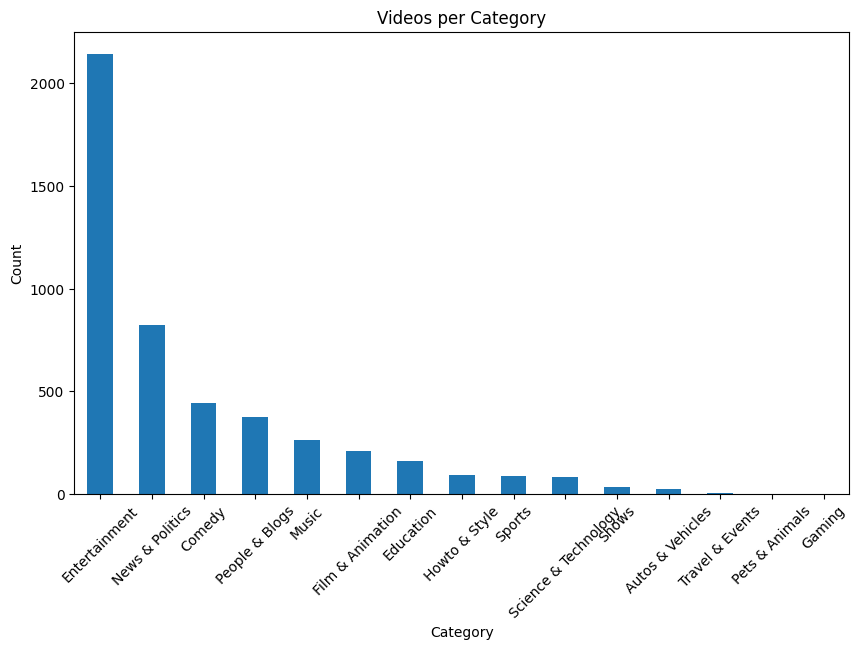

In [79]:
import matplotlib.pyplot as plt

counts = dfc['category_name'].value_counts()
plt.figure(figsize=(10,6))
counts.plot(kind='bar')
plt.title('Videos per Category')
plt.xlabel('Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

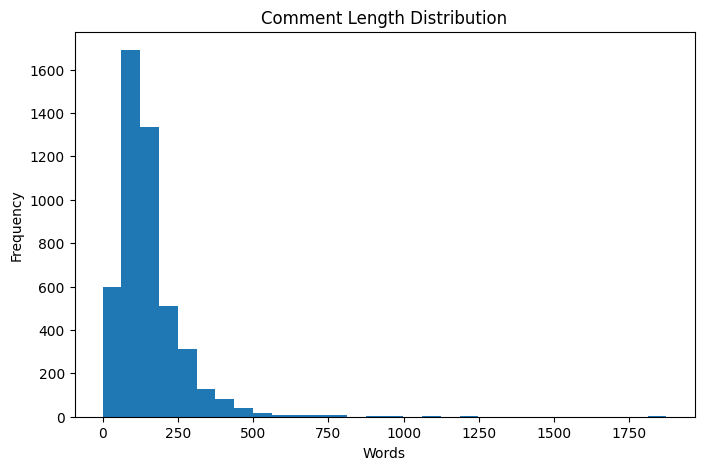

In [80]:
dfc['comment_length'] = dfc['clean_text'].apply(
    lambda x: len(x.split())
)
plt.figure(figsize=(8,5))
plt.hist(dfc['comment_length'], bins=30)
plt.title("Comment Length Distribution")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.show()

**Model Training**

In [81]:
from sklearn.model_selection import train_test_split
X = dfc['clean_text']
y = dfc['category_name']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

##**MODEL 1 — TF-IDF + Logistic Regression**

In [82]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
lr_model = Pipeline([

    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2)
    )),

    ('clf', LogisticRegression(
        max_iter=3000
    ))

])

lr_model.fit(X_train, y_train)
pred_lr = lr_model.predict(X_test)

In [83]:
from sklearn.metrics import classification_report
print(classification_report(
    y_test,
    pred_lr
))

                      precision    recall  f1-score   support

    Autos & Vehicles       0.00      0.00      0.00         5
              Comedy       0.00      0.00      0.00        89
           Education       0.00      0.00      0.00        33
       Entertainment       0.45      0.96      0.61       429
    Film & Animation       0.00      0.00      0.00        42
       Howto & Style       0.00      0.00      0.00        18
               Music       0.00      0.00      0.00        53
     News & Politics       0.23      0.05      0.08       165
      People & Blogs       0.00      0.00      0.00        75
Science & Technology       0.00      0.00      0.00        17
               Shows       0.00      0.00      0.00         7
              Sports       0.00      0.00      0.00        18
     Travel & Events       0.00      0.00      0.00         1

            accuracy                           0.44       952
           macro avg       0.05      0.08      0.05       952
      

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


##**MODEL 2 — TF-IDF + Linear SVM**

In [84]:
from sklearn.svm import LinearSVC
svm_model = Pipeline([

    ('tfidf', TfidfVectorizer(
        max_features=10000,
        ngram_range=(1,2)
    )),

    ('clf', LinearSVC(class_weight='balanced', max_iter=3000))

])
svm_model.fit(X_train, y_train)
pred_svm = svm_model.predict(X_test)

##**MODEL 3 — TF-IDF + Random Forest**

In [85]:
from sklearn.ensemble import RandomForestClassifier
rf_model = Pipeline([

    ('tfidf', TfidfVectorizer(
        max_features=5000
    )),

    ('clf', RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42
    ))

])
rf_model.fit(X_train, y_train)
pred_rf = rf_model.predict(X_test)

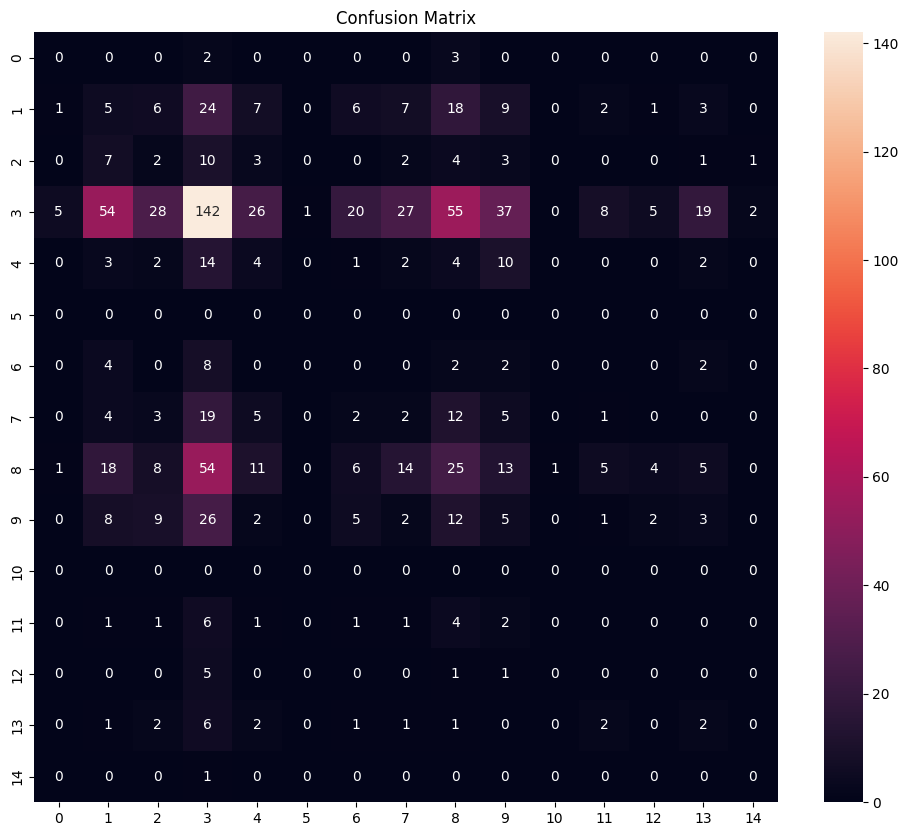

In [86]:
from sklearn.metrics import confusion_matrix

import seaborn as sns

cm = confusion_matrix(
    y_test,
    pred_svm
)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title('Confusion Matrix')

plt.show()

Severe Class Imbalance

Class 3 dominates entirely — it has the most samples and the model predicts class 3 obsessively

Classes 0, 5, 10, 14 have near-zero predictions — the model barely learned them at all

##**MODEL 4 — Sentence-BERT Embeddings**

In [45]:
!pip install sentence-transformers

In [88]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer(
    'all-MiniLM-L6-v2'
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [89]:
X_embeddings = model.encode(
    dfc['clean_text'].tolist(),
    show_progress_bar=True
)
print(X_embeddings.shape)

Batches:   0%|          | 0/149 [00:00<?, ?it/s]

(4760, 384)


In [90]:
from sklearn.linear_model import LogisticRegression
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
clf = LogisticRegression(
    max_iter=3000
)
clf.fit(
    X_train,
    y_train
)
pred_sbert = clf.predict(X_test)

##**MODEL 5 — Sentence-BERT + XGBoost**

In [91]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y_encoded = le.fit_transform(y)
X_train, X_test, y_train, y_test = train_test_split(
    X_embeddings,
    y_encoded,
    test_size=0.2,
    stratify=y_encoded,
    random_state=42
)

xgb=XGBClassifier(n_estimators=200, max_depth=3,
              learning_rate=0.05, subsample=0.8,
              colsample_bytree=0.8, reg_lambda=1.0)

xgb.fit(
    X_train,
    y_train
)
pred_xgb= xgb.predict(X_test)

###**COMPARING THE MODELS**

In [92]:
y_test_labels = le.inverse_transform(y_test)

In [93]:
from sklearn.metrics import accuracy_score
results = {

    'Logistic Regression':
        accuracy_score(y_test_labels,pred_lr),

    'Linear SVM':
        accuracy_score(y_test_labels,pred_svm),

    'Random Forest':
        accuracy_score(y_test_labels,pred_rf),

    'SBERT + LR':
        accuracy_score(y_test_labels,pred_sbert),

    'SBERT + XGB':
        accuracy_score(y_test,pred_xgb)
}
results

{'Logistic Regression': 0.44012605042016806,
 'Linear SVM': 0.19642857142857142,
 'Random Forest': 0.45063025210084034,
 'SBERT + LR': 0.44537815126050423,
 'SBERT + XGB': 0.40861344537815125}

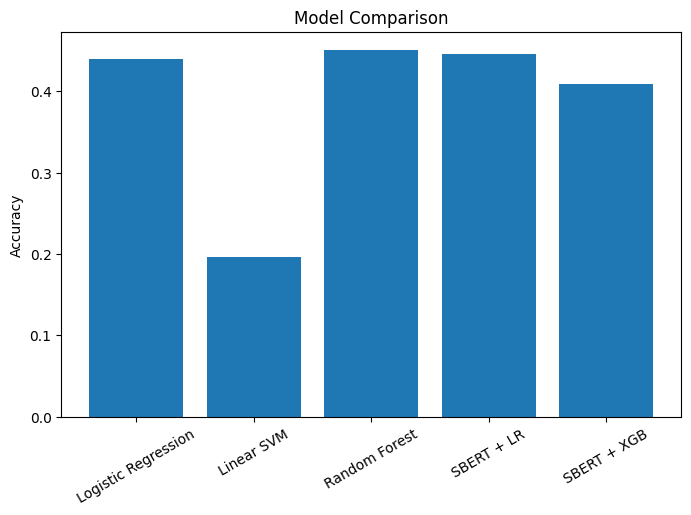

In [94]:
plt.figure(figsize=(8,5))

plt.bar(
    results.keys(),
    results.values()
)

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.xticks(rotation=30)

plt.show()

In [95]:
train_pred_xgb = xgb.predict(X_train)
from sklearn.metrics import accuracy_score
print(
    "Train:",
    accuracy_score(y_train, train_pred_xgb)
)

print(
    "Test:",
    accuracy_score(y_test, pred_xgb)
)

Train: 0.5603991596638656
Test: 0.40861344537815125


**Check for Overfitting for other models**

In [96]:
# For TF-IDF models
X_train_text, X_test_text, y_train_text, y_test_text = train_test_split(
    dfc['clean_text'],
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

# For SBERT models
X_train_emb, X_test_emb, y_train_emb, y_test_emb = train_test_split(
    X_embeddings,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
from sklearn.metrics import accuracy_score

all_models = [

    ("TFIDF + LR",
     lr_model,
     X_train_text,
     X_test_text,
     y_train_text,
     y_test_text),

    ("TFIDF + SVM",
     svm_model,
     X_train_text,
     X_test_text,
     y_train_text,
     y_test_text),

    ("TFIDF + RF",
     rf_model,
     X_train_text,
     X_test_text,
     y_train_text,
     y_test_text)

]

for name, model, Xtr, Xte, ytr, yte in all_models:

    train_acc = accuracy_score(
        ytr,
        model.predict(Xtr)
    )

    test_acc = accuracy_score(
        yte,
        model.predict(Xte)
    )

    print(f"\n{name}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Test Accuracy : {test_acc:.4f}")
    print(f"Gap           : {train_acc-test_acc:.4f}")


TFIDF + LR
Train Accuracy: 0.4908
Test Accuracy : 0.4401
Gap           : 0.0507

TFIDF + SVM
Train Accuracy: 0.6415
Test Accuracy : 0.1964
Gap           : 0.4451

TFIDF + RF
Train Accuracy: 0.4501
Test Accuracy : 0.4506
Gap           : -0.0005


In [98]:
from sklearn.metrics import accuracy_score
y_train_labels = le.inverse_transform(y_train)
# Predictions on training data
train_pred = clf.predict(X_train)

# Predictions on test data
test_pred = clf.predict(X_test)

train_acc = accuracy_score(
    y_train_labels,
    train_pred
)

test_acc = accuracy_score(
    y_test_labels,
    test_pred
)

print("SBERT + Logistic Regression")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy : {test_acc:.4f}")
print(f"Gap           : {train_acc - test_acc:.4f}")

SBERT + Logistic Regression
Train Accuracy: 0.4527
Test Accuracy : 0.4454
Gap           : 0.0074


1.SBERT + Logistic Regression achieved the highest test accuracy (44.54%) with a minimal train-test gap (0.74%), indicating excellent generalization.

2.TF-IDF + Logistic Regression also performed well (44.01% accuracy) and showed low overfitting, making it a strong baseline model.

3.TF-IDF + SVM exhibited severe overfitting, with a large train-test accuracy gap of 44.51%, resulting in poor generalization.

4.SBERT + XGBoost achieved moderate accuracy (40.86%) but showed signs of overfitting due to its higher model complexity.

5.Overall, simpler Logistic Regression classifiers generalized better than more complex models, highlighting the importance of feature representation over classifier complexity for this dataset.